# Q3: Gender vs Sadness/Hopelessness
Two-proportion z-test analysis

In [6]:
pip install xlrd

   ---------------------------------------- 0.0/96.6 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/96.6 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/96.6 kB ? eta -:--:--
   ------------ --------------------------- 30.7/96.6 kB 262.6 kB/s eta 0:00:01
   --------------------------------- ------ 81.9/96.6 kB 573.4 kB/s eta 0:00:01
   ---------------------------------------- 96.6/96.6 kB 553.3 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 1. Load Dataset
We load the cleaned dataset for analysis.

In [8]:
import pandas as pd

df = pd.read_csv("../data/processed/q3_cleaned_data.xls")

df.head()

,WhatIsYourSex,SadOrHopeless,SadOrHopeless_Recoded
0,2.0,1.0,1
1,2.0,2.0,0
2,2.0,1.0,1
3,1.0,1.0,1
4,1.0,1.0,1


In [14]:
df.columns

df["WhatIsYourSex"] = df["WhatIsYourSex"].astype(int)

male = df[df["WhatIsYourSex"] == 1]
female = df[df["WhatIsYourSex"] == 2]

df["SadOrHopeless_Recoded"].head()

0    1
1    0
2    1
3    1
4    1
Name: SadOrHopeless_Recoded, dtype: int64

In [15]:
male_yes = male["SadOrHopeless_Recoded"].sum()
female_yes = female["SadOrHopeless_Recoded"].sum()

male_n = len(male)
female_n = len(female)

male_prop = male_yes / male_n
female_prop = female_yes / female_n

male_prop, female_prop

(0.37175792507204614, 0.22733207601914987)

In [16]:
df["SadOrHopeless_Recoded"].head()

0    1
1    0
2    1
3    1
4    1
Name: SadOrHopeless_Recoded, dtype: int64

In [17]:
from statsmodels.stats.proportion import proportions_ztest

count = [male_yes, female_yes]
nobs = [male_n, female_n]

z_stat, p_value = proportions_ztest(count, nobs)

print("Z:", z_stat)
print("P-value:", p_value)

Z: 18.537353945089173
P-value: 1.0317465439640541e-76


In [18]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    male_yes, male_n,
    female_yes, female_n,
    method="wald"
)

ci_low, ci_high

(0.12935373838769065, 0.15949795971810188)

In [19]:
diff = male_prop - female_prop
diff

0.14442584905289627

In [22]:
import os

os.makedirs("../outputs/figures", exist_ok=True)

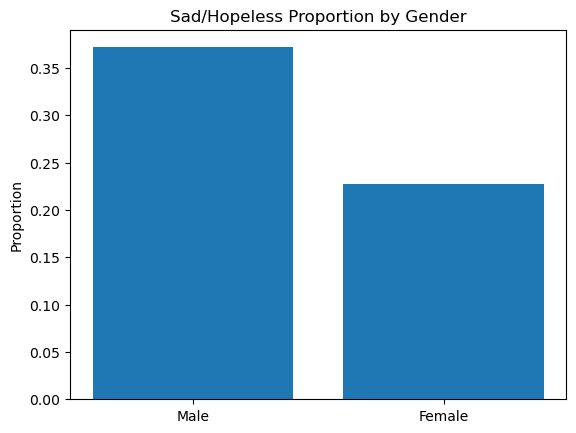

In [23]:
import matplotlib.pyplot as plt

plt.bar(["Male", "Female"], [male_prop, female_prop])
plt.title("Sad/Hopeless Proportion by Gender")
plt.ylabel("Proportion")

plt.savefig("../outputs/figures/q3_bar.png", dpi=300, bbox_inches="tight")
plt.show()